In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity

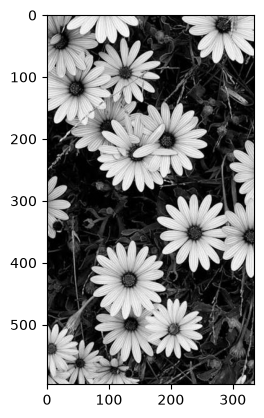

In [2]:
image = cv2.imread('images.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap='gray')
plt.show()

In [3]:
# Шум Гаусса
mean = 0 # мю
stddev = 100 # сигма
noise_gauss = np.zeros(image_gray.shape, np.uint8) 
cv2.randn(noise_gauss, mean, stddev)
print(noise_gauss)

[[  0  16   0 ...   0  61   0]
 [ 21   0 228 ...   0 140  83]
 [  0 134  23 ...   0   0  68]
 ...
 [  0   0  75 ... 146   0   0]
 [ 73  54  19 ...   0  17   0]
 [197  27 122 ...   0   0   0]]


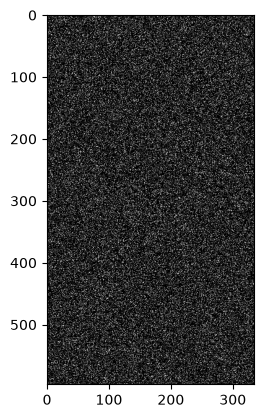

In [4]:
plt.imshow(noise_gauss, cmap="gray")

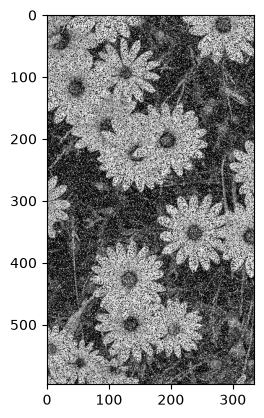

In [5]:
image_noise_gauss = image_gray + noise_gauss
plt.imshow(image_noise_gauss, cmap="gray")
plt.show()

In [6]:
# Постоянный шум
noise_uniform = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise_uniform, 0, 100)
print(noise_uniform)

[[46  0 32 ... 93 39 45]
 [67 82 55 ... 44  1  3]
 [56 27  6 ... 35 91  1]
 ...
 [16 88 29 ... 94 26 32]
 [87 90 60 ... 74 45 34]
 [26 90 51 ... 80 84 73]]


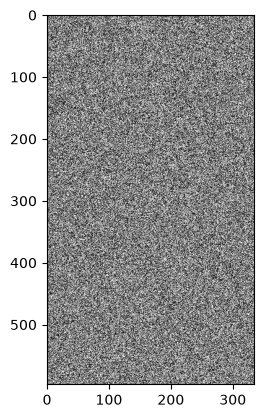

In [7]:
plt.imshow(noise_uniform, cmap="gray")
plt.show()

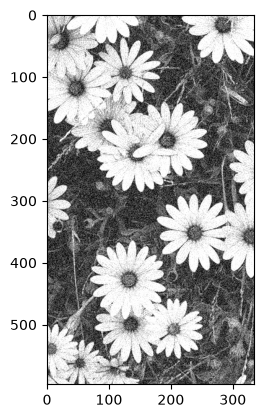

In [8]:
image_noise_uniform = cv2.add(image_gray, noise_uniform)
plt.imshow(image_noise_uniform, cmap="gray")
plt.show()

In [9]:
# Медианный фильтр
image_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 3)
image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
image_gauss_median_7 = cv2.medianBlur(image_noise_gauss, 7)

In [10]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, медианный фильтр) изображение
mse_gauss_median_cleared_3 = mean_squared_error(image_gray, image_gauss_median_3)
(ssim_gauss_median_cleared_3, diff) = structural_similarity(image_gray, image_gauss_median_3, full=True)
print(mse_gauss_median_cleared_3, ssim_gauss_median_cleared_3)

1497.2198054951373 0.4340016346025542


In [11]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, медианный фильтр) изображение
mse_gauss_median_cleared_5 = mean_squared_error(image_gray, image_gauss_median_5)
(ssim_gauss_median_cleared_5, diff) = structural_similarity(image_gray, image_gauss_median_5, full=True)
print(mse_gauss_median_cleared_5, ssim_gauss_median_cleared_5)

1070.3643291082276 0.4519306827702117


In [12]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, медианный фильтр) изображение
mse_gauss_median_cleared_7 = mean_squared_error(image_gray, image_gauss_median_7)
(ssim_gauss_median_cleared_7, diff) = structural_similarity(image_gray, image_gauss_median_7, full=True)
print(mse_gauss_median_cleared_7, ssim_gauss_median_cleared_7)

1143.0588914722869 0.4086978554421307


In [13]:
# Медианный фильтр
image_uniform_median_3 = cv2.medianBlur(image_noise_uniform, 3)
image_uniform_median_5 = cv2.medianBlur(image_noise_uniform, 5)
image_uniform_median_7 = cv2.medianBlur(image_noise_uniform, 7)

In [14]:
# Сравнение: исходное и отфильтрованное (постоянный шум, медианный фильтр) изображение
mse_uniform_median_cleared_3 = mean_squared_error(image_gray, image_uniform_median_3)
(ssim_uniform_median_cleared_3, diff) = structural_similarity(image_gray, image_uniform_median_3, full=True)
print(mse_uniform_median_cleared_3, ssim_uniform_median_cleared_3)

2472.884392109803 0.508369273192605


In [15]:
# Сравнение: исходное и отфильтрованное (постоянный шум, медианный фильтр) изображение
mse_uniform_median_cleared_5 = mean_squared_error(image_gray, image_uniform_median_5)
(ssim_uniform_median_cleared_5, diff) = structural_similarity(image_gray, image_uniform_median_5, full=True)
print(mse_uniform_median_cleared_5, ssim_uniform_median_cleared_5)

2669.5044076101904 0.439825862170048


In [16]:
# Сравнение: исходное и отфильтрованное (постоянный шум, медианный фильтр) изображение
mse_uniform_median_cleared_7 = mean_squared_error(image_gray, image_uniform_median_7)
(ssim_uniform_median_cleared_7, diff) = structural_similarity(image_gray, image_uniform_median_7, full=True)
print(mse_uniform_median_cleared_7, ssim_uniform_median_cleared_7)

2902.234795869897 0.38245727529009144


In [17]:
# Фильтр Гаусса
image_gauss_gauss_3 = cv2.GaussianBlur(image_noise_gauss,(3,3),0)
image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss,(5,5),0)
image_gauss_gauss_7 = cv2.GaussianBlur(image_noise_gauss,(7,7),0)

In [18]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, фильтр Гаусса) изображение
mse_gauss_gauss_cleared_3 = mean_squared_error(image_gray, image_gauss_gauss_3)
(ssim_gauss_gauss_cleared_3, diff) = structural_similarity(image_gray, image_gauss_gauss_3, full=True)
print(mse_gauss_gauss_cleared_3, ssim_gauss_gauss_cleared_3)

2323.929958248956 0.34778217483748536


In [19]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, фильтр Гаусса) изображение
mse_gauss_gauss_cleared_5 = mean_squared_error(image_gray, image_gauss_gauss_5)
(ssim_gauss_gauss_cleared_5, diff) = structural_similarity(image_gray, image_gauss_gauss_5, full=True)
print(mse_gauss_gauss_cleared_5, ssim_gauss_gauss_cleared_5)

2174.0259306482662 0.36135820620905085


In [20]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, фильтр Гаусса) изображение
mse_gauss_gauss_cleared_7 = mean_squared_error(image_gray, image_gauss_gauss_7)
(ssim_gauss_gauss_cleared_7, diff) = structural_similarity(image_gray, image_gauss_gauss_7, full=True)
print(mse_gauss_gauss_cleared_7, ssim_gauss_gauss_cleared_7)

2184.766434160854 0.3521641132351282


In [21]:
# Фильтр Гаусса
image_uniform_gauss_3 = cv2.GaussianBlur(image_noise_uniform,(3,3),0)
image_uniform_gauss_5 = cv2.GaussianBlur(image_noise_uniform,(5,5),0)
image_uniform_gauss_7 = cv2.GaussianBlur(image_noise_uniform,(7,7),0)

In [22]:
# Сравнение: исходное и отфильтрованное (постоянный шум, фильтр Гаусса) изображение
mse_uniform_gauss_cleared_3 = mean_squared_error(image_gray, image_uniform_gauss_3)
(ssim_uniform_gauss_cleared_3, diff) = structural_similarity(image_gray, image_uniform_gauss_3, full=True)
print(mse_uniform_gauss_cleared_3, ssim_uniform_gauss_cleared_3)

2214.1191779794494 0.5722415719747066


In [23]:
# Сравнение: исходное и отфильтрованное (постоянный шум, фильтр Гаусса) изображение
mse_uniform_gauss_cleared_5 = mean_squared_error(image_gray, image_uniform_gauss_5)
(ssim_uniform_gauss_cleared_5, diff) = structural_similarity(image_gray, image_uniform_gauss_5, full=True)
print(mse_uniform_gauss_cleared_5, ssim_uniform_gauss_cleared_5)

2296.152133803345 0.5364308126153069


In [24]:
# Сравнение: исходное и отфильтрованное (постоянный шум, фильтр Гаусса) изображение
mse_uniform_gauss_cleared_7 = mean_squared_error(image_gray, image_uniform_gauss_7)
(ssim_uniform_gauss_cleared_7, diff) = structural_similarity(image_gray, image_uniform_gauss_7, full=True)
print(mse_uniform_gauss_cleared_7, ssim_uniform_gauss_cleared_7)

2437.4502012550315 0.4828276346081359


In [25]:
# Билатериальный фильтр
image_gauss_bilat_1 = cv2.bilateralFilter(image_noise_gauss,49,150,150)
image_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss,25,150,150)
image_gauss_bilat_3 = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [26]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, билатериальный фильтр) изображение
mse_gauss_bilat_cleared_1 = mean_squared_error(image_gray, image_gauss_bilat_1)
(ssim_gauss_bilat_cleared_1, diff) = structural_similarity(image_gray, image_gauss_bilat_1, full=True)
print(mse_gauss_bilat_cleared_1, ssim_gauss_bilat_cleared_1)

3426.081427035676 0.1870182503935756


In [27]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, билатериальный фильтр) изображение
mse_gauss_bilat_cleared_2 = mean_squared_error(image_gray, image_gauss_bilat_2)
(ssim_gauss_bilat_cleared_2, diff) = structural_similarity(image_gray, image_gauss_bilat_2, full=True)
print(mse_gauss_bilat_cleared_2, ssim_gauss_bilat_cleared_2)

2853.873686842171 0.20628341432076225


In [28]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, билатериальный фильтр) изображение
mse_gauss_bilat_cleared_3 = mean_squared_error(image_gray, image_gauss_bilat_3)
(ssim_gauss_bilat_cleared_3, diff) = structural_similarity(image_gray, image_gauss_bilat_3, full=True)
print(mse_gauss_bilat_cleared_3, ssim_gauss_bilat_cleared_3)

3180.555613890347 0.25551401311591354


In [29]:
# Билатериальный фильтр
image_uniform_bilat_1 = cv2.bilateralFilter(image_noise_uniform,49,150,150)
image_uniform_bilat_2 = cv2.bilateralFilter(image_noise_uniform,25,150,150)
image_uniform_bilat_3 = cv2.bilateralFilter(image_noise_uniform,9,75,75)

In [30]:
# Сравнение: исходное и отфильтрованное (постоянный шум, билатериальный фильтр) изображение
mse_uniform_bilat_cleared_1 = mean_squared_error(image_gray, image_uniform_bilat_1)
(ssim_uniform_bilat_cleared_1, diff) = structural_similarity(image_gray, image_uniform_bilat_1, full=True)
print(mse_uniform_bilat_cleared_1, ssim_uniform_bilat_cleared_1)

3920.2766919172977 0.2793808314641072


In [31]:
# Сравнение: исходное и отфильтрованное (постоянный шум, билатериальный фильтр) изображение
mse_uniform_bilat_cleared_2 = mean_squared_error(image_gray, image_uniform_bilat_2)
(ssim_uniform_bilat_cleared_2, diff) = structural_similarity(image_gray, image_uniform_bilat_2, full=True)
print(mse_uniform_bilat_cleared_2, ssim_uniform_bilat_cleared_2)

3404.7528188204706 0.2786846066707456


In [32]:
# Сравнение: исходное и отфильтрованное (постоянный шум, билатериальный фильтр) изображение
mse_uniform_bilat_cleared_3 = mean_squared_error(image_gray, image_uniform_bilat_3)
(ssim_uniform_bilat_cleared_3, diff) = structural_similarity(image_gray, image_uniform_bilat_3, full=True)
print(mse_uniform_bilat_cleared_3, ssim_uniform_bilat_cleared_3)

2315.9464386609666 0.5002338103788081


In [33]:
# Фильтр нелокальных средних
image_gauss_nlm_1 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
image_gauss_nlm_2 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 120)
image_gauss_nlm_3 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 2)

In [34]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, фильтр нелокальных средних) изображение
mse_gauss_nlm_cleared_1 = mean_squared_error(image_gray, image_gauss_nlm_1)
(ssim_gauss_nlm_cleared_1, diff) = structural_similarity(image_gray, image_gauss_nlm_1, full=True)
print(mse_gauss_nlm_cleared_1, ssim_gauss_nlm_cleared_1)

5651.313907847696 0.19542202511498877


In [35]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, фильтр нелокальных средних) изображение
mse_gauss_nlm_cleared_2 = mean_squared_error(image_gray, image_gauss_nlm_2)
(ssim_gauss_nlm_cleared_2, diff) = structural_similarity(image_gray, image_gauss_nlm_2, full=True)
print(mse_gauss_nlm_cleared_2, ssim_gauss_nlm_cleared_2)

3113.3144178604466 0.18561815409558413


In [36]:
# Сравнение: исходное и отфильтрованное (гауссовский шум, фильтр нелокальных средних) изображение
mse_gauss_nlm_cleared_3 = mean_squared_error(image_gray, image_gauss_nlm_3)
(ssim_gauss_nlm_cleared_3, diff) = structural_similarity(image_gray, image_gauss_nlm_3, full=True)
print(mse_gauss_nlm_cleared_3, ssim_gauss_nlm_cleared_3)

5652.605990149754 0.19537001500234302


In [37]:
# Фильтр нелокальных средних
image_uniform_nlm_1 = cv2.fastNlMeansDenoising(image_noise_uniform, h = 20)
image_uniform_nlm_2 = cv2.fastNlMeansDenoising(image_noise_uniform, h = 120)
image_uniform_nlm_3 = cv2.fastNlMeansDenoising(image_noise_uniform, h = 2)

In [38]:
# Сравнение: исходное и отфильтрованное (постоянный шум, фильтр нелокальных средних) изображение
mse_uniform_nlm_cleared_1 = mean_squared_error(image_gray, image_uniform_nlm_1)
(ssim_uniform_nlm_cleared_1, diff) = structural_similarity(image_gray, image_uniform_nlm_1, full=True)
print(mse_uniform_nlm_cleared_1, ssim_uniform_nlm_cleared_1)

2348.04793119828 0.5106263301737728


In [39]:
# Сравнение: исходное и отфильтрованное (постоянный шум, фильтр нелокальных средних) изображение
mse_uniform_nlm_cleared_2 = mean_squared_error(image_gray, image_uniform_nlm_2)
(ssim_uniform_nlm_cleared_2, diff) = structural_similarity(image_gray, image_uniform_nlm_2, full=True)
print(mse_uniform_nlm_cleared_2, ssim_uniform_nlm_cleared_2)

3344.223540588515 0.24585938463063797


In [40]:
# Сравнение: исходное и отфильтрованное (постоянный шум, фильтр нелокальных средних) изображение
mse_uniform_nlm_cleared_3 = mean_squared_error(image_gray, image_uniform_nlm_3)
(ssim_uniform_nlm_cleared_3, diff) = structural_similarity(image_gray, image_uniform_nlm_3, full=True)
print(mse_uniform_nlm_cleared_3, ssim_uniform_nlm_cleared_3)

2587.5726293157327 0.49100706723517945


In [41]:
# Лучший результат для изображения с шумом Гаусса показал медианный фильтр
# Лучший результат для изображения с постоянным шумом показал фильтр Гаусса

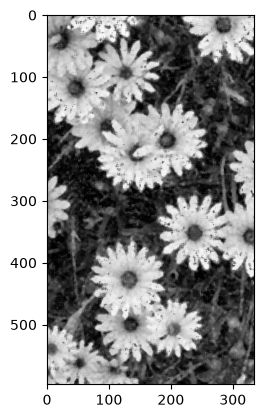

In [42]:
plt.imshow(image_gauss_median_5, cmap="gray")
plt.show()

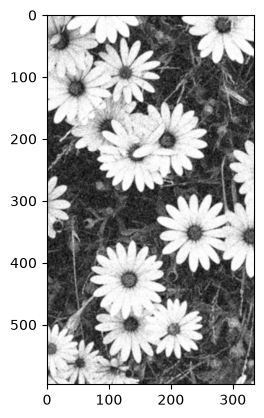

In [43]:
plt.imshow(image_uniform_gauss_3, cmap="gray")
plt.show()